# False Nearest Neighbors — Test Suite

This notebook validates `false_nearest_neighbors` from `fnn.py` on a
Lorenz attractor, noisy variants, finite samples, parameter changes,
white noise, and invalid inputs.

Unless stated otherwise, the tests use `tau=10`, `max_m=10`,
`R_tol=15`, `A_tol=2`, `theiler=10`, and a `1%` FNN selection
threshold.

In [1]:
import sys
from importlib import import_module
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.integrate import solve_ivp


def find_repo_root(start):
    """Find the repository root."""
    for path in (start, *start.parents):
        if (path / "phase1" / "src").is_dir():
            return path
    raise FileNotFoundError("Repository root was not found.")


def lorenz_rhs(_, state):
    """Return the standard Lorenz derivatives."""
    x, y, z = state
    return (
        10.0 * (y - x),
        x * (28.0 - z) - y,
        x * y - (8.0 / 3.0) * z,
    )


def generate_lorenz(n_samples, discard=2000, dt=0.01):
    """Generate the x coordinate of a Lorenz trajectory."""
    total_samples = n_samples + discard
    time = np.arange(total_samples, dtype=float) * dt
    solution = solve_ivp(
        lorenz_rhs,
        (time[0], time[-1]),
        (1.0, 1.0, 1.0),
        t_eval=time,
        rtol=1e-9,
        atol=1e-12,
    )
    if not solution.success:
        raise RuntimeError("Lorenz integration failed.")
    return time[discard:], solution.y[0, discard:]


def run_fnn(
    signal,
    tau,
    r_tol=15.0,
    a_tol=2.0,
    theiler=None,
):
    """Run FNN with the shared test configuration."""
    if theiler is None:
        theiler = tau
    dims, percentages, counts, selected_m = (
        false_nearest_neighbors(
            signal,
            tau=tau,
            max_m=MAX_M,
            r_tol=r_tol,
            a_tol=a_tol,
            theiler=theiler,
            fnn_threshold=FNN_THRESHOLD,
        )
    )
    return {
        "dims": dims,
        "fnn": percentages,
        "valid": counts,
        "selected_m": selected_m,
    }


def plot_fnn_curve(result, ax, label, color=None):
    """Plot one FNN percentage curve."""
    ax.plot(
        result["dims"],
        result["fnn"],
        marker="o",
        markersize=4,
        label=label,
        color=color,
    )


REPO_ROOT = find_repo_root(Path.cwd().resolve())
repo_path = str(REPO_ROOT)
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

fnn = import_module("phase1.src.embedding.fnn")
false_nearest_neighbors = fnn.false_nearest_neighbors

BASE_SEED = 2026
TAU_REF = 10
MAX_M = 10
FNN_THRESHOLD = 1.0
BLUE = "#0072B2"
ORANGE = "#D55E00"
GREEN = "#009E73"

lorenz_time, lorenz_x = generate_lorenz(5000)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 1.2,
})

## 1. Lorenz clean signal

Use the clean Lorenz `x(t)` coordinate with fixed `tau_ref=10` and
calculate FNN for dimensions `1...10`.

,m,fnn_percent,valid_neighbors
0,1,98.4970,4990
1,2,4.1365,4980
2,3,0.0000,4970
3,4,0.0000,4960
4,5,0.0000,4950
5,6,0.0000,4940
6,7,0.0000,4930
7,8,0.0000,4920
8,9,0.0204,4910
9,10,0.3265,4900


Selected m: 3


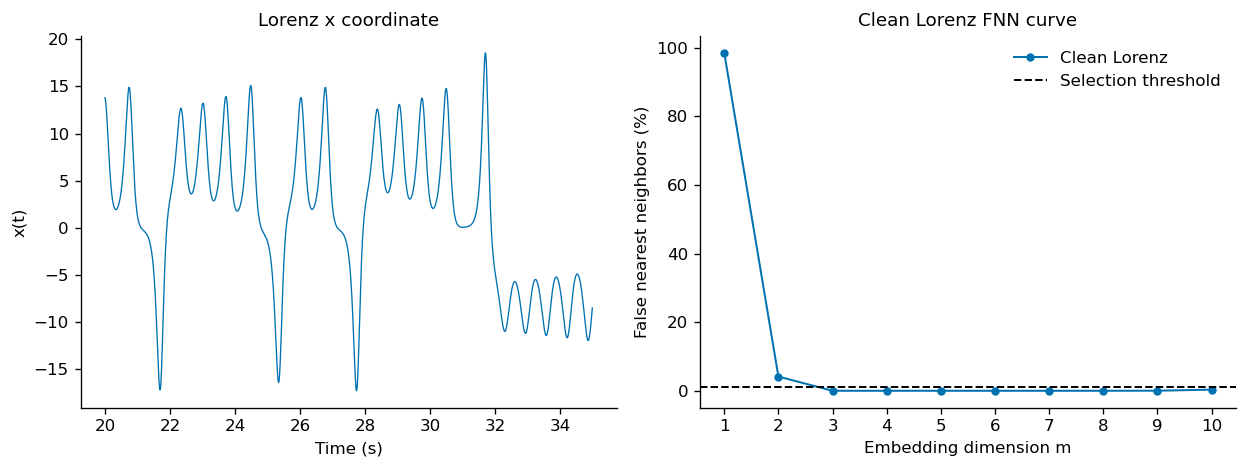

In [2]:
clean_result = run_fnn(lorenz_x, tau=TAU_REF)
clean_table = pd.DataFrame({
    "m": clean_result["dims"],
    "fnn_percent": clean_result["fnn"],
    "valid_neighbors": clean_result["valid"],
})
clean_ready = (
    clean_result["selected_m"] in {2, 3, 4}
    and clean_result["fnn"][-1] <= FNN_THRESHOLD
)
assert clean_ready
display(clean_table.round(4))
print(f"Selected m: {clean_result['selected_m']}")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
axes[0].plot(
    lorenz_time[:1500],
    lorenz_x[:1500],
    color=BLUE,
    linewidth=0.8,
)
axes[0].set(
    xlabel="Time (s)",
    ylabel="x(t)",
    title="Lorenz x coordinate",
)

plot_fnn_curve(clean_result, axes[1], "Clean Lorenz", BLUE)
axes[1].axhline(
    FNN_THRESHOLD,
    color="black",
    linestyle="--",
    label="Selection threshold",
)
axes[1].set(
    xlabel="Embedding dimension m",
    ylabel="False nearest neighbors (%)",
    title="Clean Lorenz FNN curve",
    xticks=clean_result["dims"],
)
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

## 2. Lorenz with Gaussian noise

Add one fixed Gaussian noise realization at `40`, `30`, `20`, and
`10 dB`. Signal-to-noise ratio uses the signal and noise standard
deviations.

,snr_db,noise_std,selected_m,minimum_fnn,mean_fnn_m6_to_m10
0,40,0.0786,3,0.0000,0.0694
1,30,0.2487,3,0.0000,0.0735
2,20,0.7864,4,0.0000,0.0816
3,10,2.4869,5,0.4656,0.9483


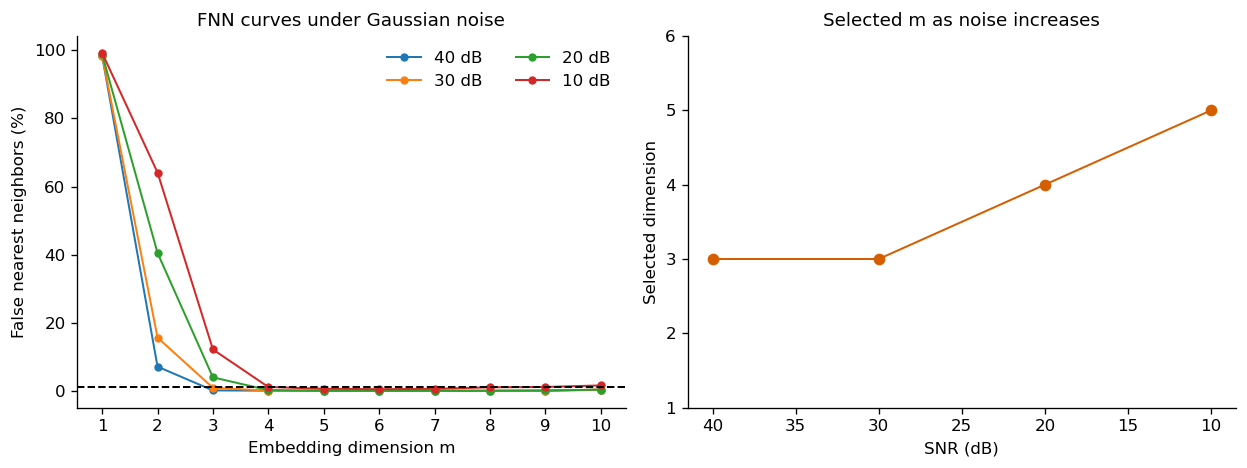

In [3]:
noise_rng = np.random.default_rng(BASE_SEED)
standard_noise = noise_rng.normal(size=len(lorenz_x))
snr_values = (40, 30, 20, 10)
noise_results = {}
noise_records = []

for snr_db in snr_values:
    noise_std = np.std(lorenz_x) * 10.0 ** (-snr_db / 20.0)
    noisy_signal = lorenz_x + noise_std * standard_noise
    result = run_fnn(noisy_signal, tau=TAU_REF)
    noise_results[snr_db] = result
    tail = result["fnn"][result["dims"] >= 6]
    noise_records.append({
        "snr_db": snr_db,
        "noise_std": noise_std,
        "selected_m": result["selected_m"],
        "minimum_fnn": result["fnn"].min(),
        "mean_fnn_m6_to_m10": tail.mean(),
    })

noise_table = pd.DataFrame(noise_records)
selected_noise_m = noise_table["selected_m"].to_numpy()
noise_ready = (
    np.isfinite(selected_noise_m).all()
    and (np.diff(selected_noise_m) >= 0).all()
    and noise_table.iloc[-1]["mean_fnn_m6_to_m10"]
    >= noise_table.iloc[0]["mean_fnn_m6_to_m10"]
)
assert noise_ready
display(noise_table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
for snr_db in snr_values:
    plot_fnn_curve(
        noise_results[snr_db],
        axes[0],
        f"{snr_db} dB",
    )
axes[0].axhline(
    FNN_THRESHOLD,
    color="black",
    linestyle="--",
)
axes[0].set(
    xlabel="Embedding dimension m",
    ylabel="False nearest neighbors (%)",
    title="FNN curves under Gaussian noise",
    xticks=np.arange(1, MAX_M + 1),
)
axes[0].legend(frameon=False, ncol=2)

axes[1].plot(
    noise_table["snr_db"],
    noise_table["selected_m"],
    color=ORANGE,
    marker="o",
    label="Selected m",
)
axes[1].invert_xaxis()
axes[1].set(
    xlabel="SNR (dB)",
    ylabel="Selected dimension",
    title="Selected m as noise increases",
    yticks=np.arange(1, 7),
)
fig.tight_layout()
plt.show()

## 3. Sample-size sensitivity

Evaluate clean Lorenz segments with `N=500,1000,3000,5000`. Valid
neighbor counts are reported together with the FNN curves.

,N,selected_m,valid_neighbors_m1,valid_neighbors_m10,minimum_fnn
0,500,NaN,490,400,5.9574
1,1000,2.0,990,900,0.0000
2,3000,3.0,2990,2900,0.0000
3,5000,3.0,4990,4900,0.0000


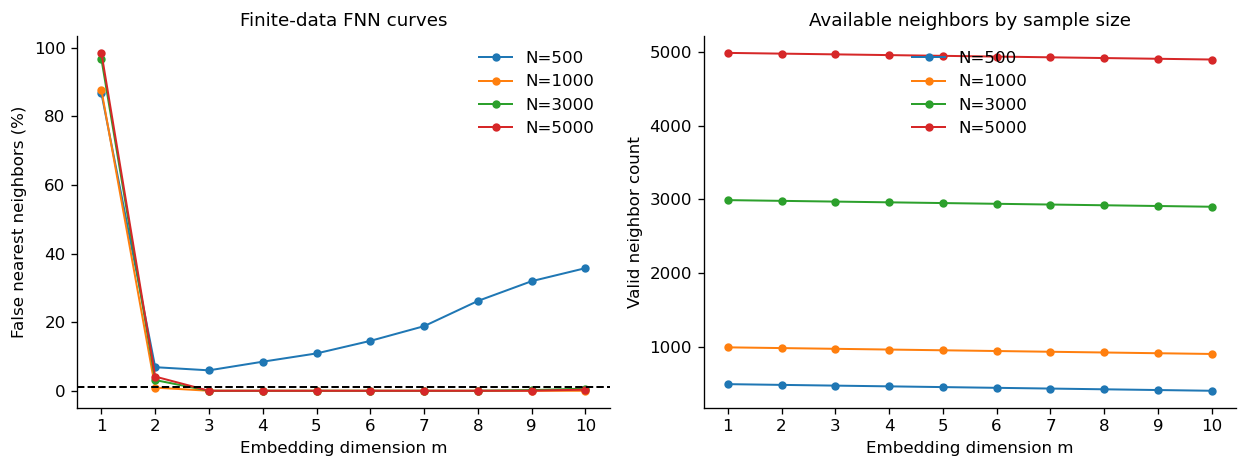

In [4]:
sample_sizes = (500, 1000, 3000, 5000)
sample_results = {}
sample_records = []

for n_samples in sample_sizes:
    result = run_fnn(lorenz_x[:n_samples], tau=TAU_REF)
    sample_results[n_samples] = result
    sample_records.append({
        "N": n_samples,
        "selected_m": result["selected_m"],
        "valid_neighbors_m1": result["valid"][0],
        "valid_neighbors_m10": result["valid"][-1],
        "minimum_fnn": result["fnn"].min(),
    })

sample_table = pd.DataFrame(sample_records)
sample_ready = (
    sample_results[3000]["selected_m"]
    == sample_results[5000]["selected_m"]
    and sample_results[5000]["selected_m"] is not None
)
assert sample_ready
display(sample_table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
for n_samples in sample_sizes:
    result = sample_results[n_samples]
    plot_fnn_curve(result, axes[0], f"N={n_samples}")
    axes[1].plot(
        result["dims"],
        result["valid"],
        marker="o",
        markersize=4,
        label=f"N={n_samples}",
    )
axes[0].axhline(
    FNN_THRESHOLD,
    color="black",
    linestyle="--",
)
axes[0].set(
    xlabel="Embedding dimension m",
    ylabel="False nearest neighbors (%)",
    title="Finite-data FNN curves",
    xticks=np.arange(1, MAX_M + 1),
)
axes[1].set(
    xlabel="Embedding dimension m",
    ylabel="Valid neighbor count",
    title="Available neighbors by sample size",
    xticks=np.arange(1, MAX_M + 1),
)
axes[0].legend(frameon=False)
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

## 4. Threshold sensitivity

Test all nine combinations of `R_tol=10,15,20` and
`A_tol=1.5,2.0,2.5` on the same clean Lorenz signal.

,R_tol,A_tol,selected_m,fnn_at_m1,fnn_at_m2,minimum_fnn
0,10.0,1.5,3,99.1383,5.7430,0.0
1,10.0,2.0,3,99.1383,5.7430,0.0
2,10.0,2.5,3,99.1383,5.7430,0.0
3,15.0,1.5,3,98.4970,4.1365,0.0
4,15.0,2.0,3,98.4970,4.1365,0.0
5,15.0,2.5,3,98.4970,4.1365,0.0
6,20.0,1.5,3,98.1363,3.0723,0.0
7,20.0,2.0,3,98.1363,3.0723,0.0
8,20.0,2.5,3,98.1363,3.0723,0.0


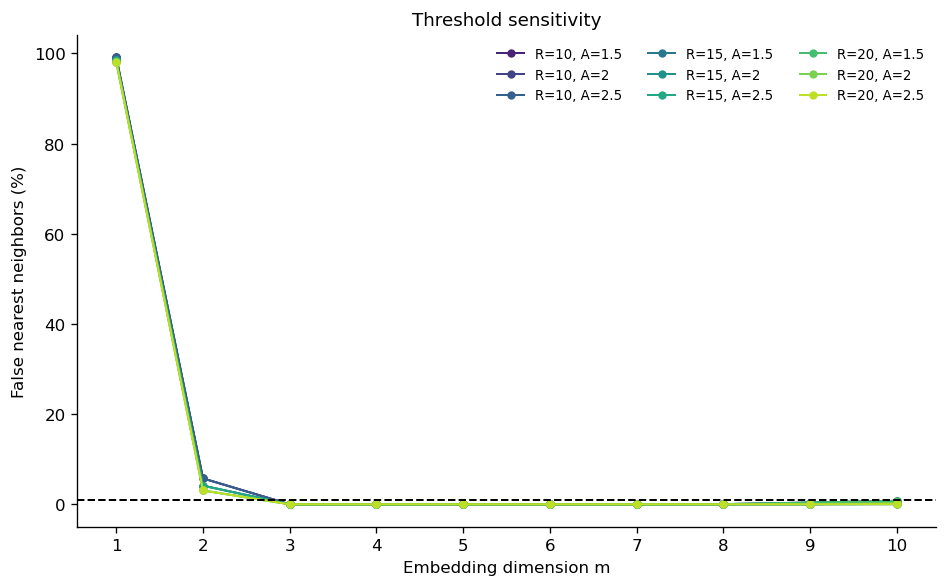

In [5]:
r_tolerances = (10.0, 15.0, 20.0)
a_tolerances = (1.5, 2.0, 2.5)
threshold_results = {}
threshold_records = []

for r_tol in r_tolerances:
    for a_tol in a_tolerances:
        result = run_fnn(
            lorenz_x,
            tau=TAU_REF,
            r_tol=r_tol,
            a_tol=a_tol,
        )
        key = (r_tol, a_tol)
        threshold_results[key] = result
        threshold_records.append({
            "R_tol": r_tol,
            "A_tol": a_tol,
            "selected_m": result["selected_m"],
            "fnn_at_m1": result["fnn"][0],
            "fnn_at_m2": result["fnn"][1],
            "minimum_fnn": result["fnn"].min(),
        })

threshold_table = pd.DataFrame(threshold_records)
threshold_ready = threshold_table["selected_m"].nunique() == 1
assert threshold_ready
display(threshold_table.round(4))

fig, ax = plt.subplots(figsize=(8.0, 5.0))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, 9))
for color, (key, result) in zip(
    colors,
    threshold_results.items(),
):
    r_tol, a_tol = key
    plot_fnn_curve(
        result,
        ax,
        f"R={r_tol:g}, A={a_tol:g}",
        color,
    )
ax.axhline(
    FNN_THRESHOLD,
    color="black",
    linestyle="--",
)
ax.set(
    xlabel="Embedding dimension m",
    ylabel="False nearest neighbors (%)",
    title="Threshold sensitivity",
    xticks=np.arange(1, MAX_M + 1),
)
ax.legend(frameon=False, ncol=3, fontsize=8)
fig.tight_layout()
plt.show()

## 5. Theiler sensitivity

Compare no temporal exclusion with `theiler=tau` and
`theiler=2*tau`. Report both FNN percentage and valid neighbor count.

,theiler,selected_m,fnn_at_m1,fnn_at_m2,valid_neighbors_m1,valid_neighbors_m3
0,0,3,98.7174,4.1365,4990,4970
1,10,3,98.4970,4.1365,4990,4970
2,20,3,98.4770,4.1365,4990,4970


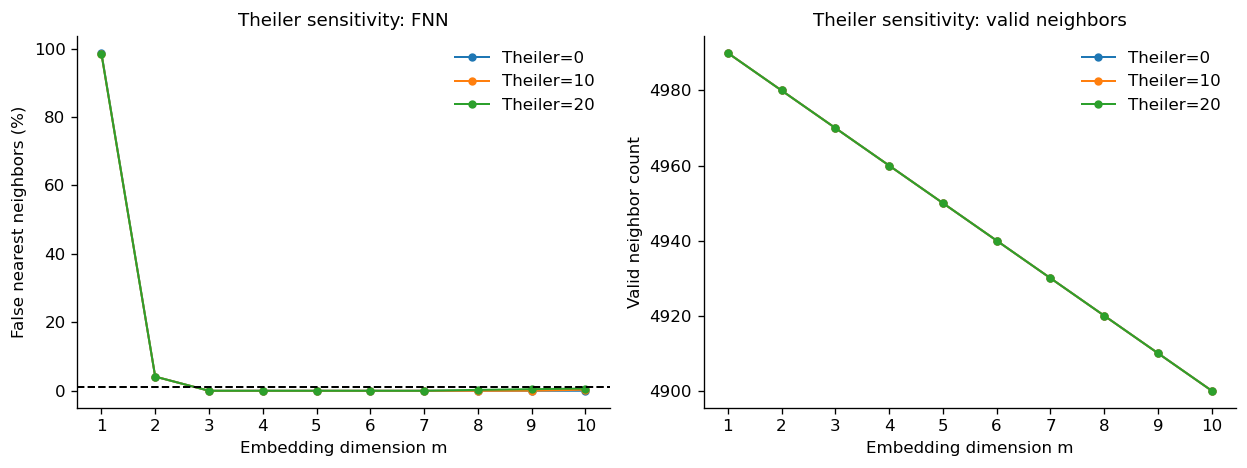

In [6]:
theiler_values = (0, TAU_REF, 2 * TAU_REF)
theiler_results = {}
theiler_records = []

for theiler_value in theiler_values:
    result = run_fnn(
        lorenz_x,
        tau=TAU_REF,
        theiler=theiler_value,
    )
    theiler_results[theiler_value] = result
    theiler_records.append({
        "theiler": theiler_value,
        "selected_m": result["selected_m"],
        "fnn_at_m1": result["fnn"][0],
        "fnn_at_m2": result["fnn"][1],
        "valid_neighbors_m1": result["valid"][0],
        "valid_neighbors_m3": result["valid"][2],
    })

theiler_table = pd.DataFrame(theiler_records)
theiler_ready = theiler_table["selected_m"].nunique() == 1
assert theiler_ready
display(theiler_table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
for theiler_value in theiler_values:
    result = theiler_results[theiler_value]
    plot_fnn_curve(
        result,
        axes[0],
        f"Theiler={theiler_value}",
    )
    axes[1].plot(
        result["dims"],
        result["valid"],
        marker="o",
        markersize=4,
        label=f"Theiler={theiler_value}",
    )
axes[0].axhline(
    FNN_THRESHOLD,
    color="black",
    linestyle="--",
)
axes[0].set(
    xlabel="Embedding dimension m",
    ylabel="False nearest neighbors (%)",
    title="Theiler sensitivity: FNN",
    xticks=np.arange(1, MAX_M + 1),
)
axes[1].set(
    xlabel="Embedding dimension m",
    ylabel="Valid neighbor count",
    title="Theiler sensitivity: valid neighbors",
    xticks=np.arange(1, MAX_M + 1),
)
axes[0].legend(frameon=False)
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

## 6. Tau sensitivity

Compare `0.5*tau_ref`, `tau_ref`, and `1.5*tau_ref`, corresponding to
integer delays `5`, `10`, and `15` samples.

,tau,selected_m,fnn_at_m1,fnn_at_m2,mean_fnn_m6_to_m10
0,5,3,97.5175,1.1824,0.0000
1,10,3,98.4970,4.1365,0.0694
2,15,3,98.8967,4.9698,0.9980


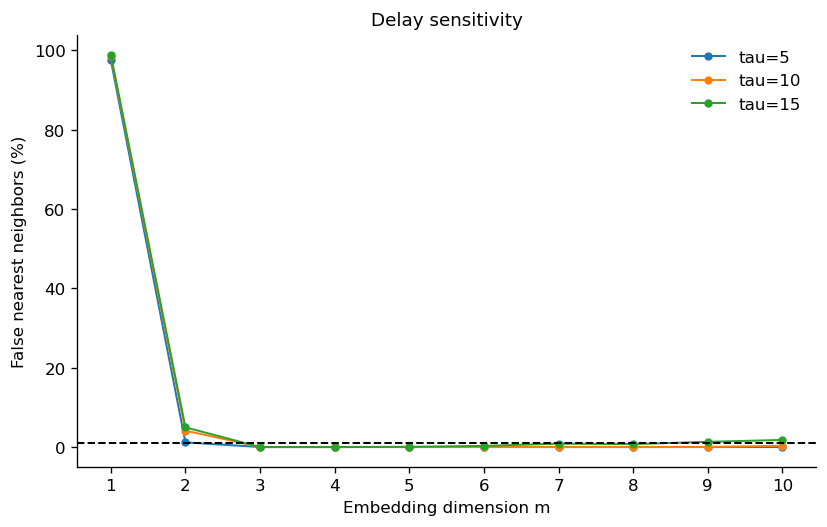

In [7]:
tau_values = (TAU_REF // 2, TAU_REF, 3 * TAU_REF // 2)
tau_results = {}
tau_records = []

for tau_value in tau_values:
    result = run_fnn(lorenz_x, tau=tau_value)
    tau_results[tau_value] = result
    tail = result["fnn"][result["dims"] >= 6]
    tau_records.append({
        "tau": tau_value,
        "selected_m": result["selected_m"],
        "fnn_at_m1": result["fnn"][0],
        "fnn_at_m2": result["fnn"][1],
        "mean_fnn_m6_to_m10": tail.mean(),
    })

tau_table = pd.DataFrame(tau_records)
tau_ready = tau_table["selected_m"].nunique() == 1
assert tau_ready
display(tau_table.round(4))

fig, ax = plt.subplots(figsize=(7.0, 4.5))
for tau_value in tau_values:
    plot_fnn_curve(
        tau_results[tau_value],
        ax,
        f"tau={tau_value}",
    )
ax.axhline(
    FNN_THRESHOLD,
    color="black",
    linestyle="--",
)
ax.set(
    xlabel="Embedding dimension m",
    ylabel="False nearest neighbors (%)",
    title="Delay sensitivity",
    xticks=np.arange(1, MAX_M + 1),
)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 7. White-noise control

Run FNN on Gaussian white noise with the same sample count, variance,
delay, and Theiler window as the clean Lorenz test.

,m,fnn_percent,valid_neighbors
0,1,99.5190,4990
1,2,73.5944,4980
2,3,28.4105,4970
3,4,17.1573,4960
4,5,17.2929,4950
5,6,20.0810,4940
6,7,22.6775,4930
7,8,26.4024,4920
8,9,34.8269,4910
9,10,44.5102,4900


Selected m: None


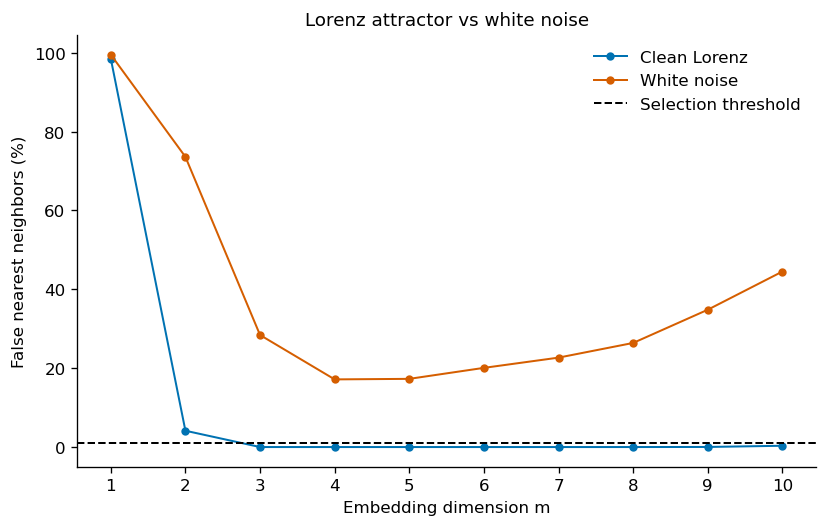

In [8]:
white_rng = np.random.default_rng(BASE_SEED)
white_noise = white_rng.normal(
    loc=np.mean(lorenz_x),
    scale=np.std(lorenz_x),
    size=len(lorenz_x),
)
white_result = run_fnn(white_noise, tau=TAU_REF)
white_table = pd.DataFrame({
    "m": white_result["dims"],
    "fnn_percent": white_result["fnn"],
    "valid_neighbors": white_result["valid"],
})
white_ready = (
    white_result["selected_m"] is None
    and white_result["fnn"].min() > FNN_THRESHOLD
)
assert white_ready
display(white_table.round(4))
print(f"Selected m: {white_result['selected_m']}")

fig, ax = plt.subplots(figsize=(7.0, 4.5))
plot_fnn_curve(clean_result, ax, "Clean Lorenz", BLUE)
plot_fnn_curve(white_result, ax, "White noise", ORANGE)
ax.axhline(
    FNN_THRESHOLD,
    color="black",
    linestyle="--",
    label="Selection threshold",
)
ax.set(
    xlabel="Embedding dimension m",
    ylabel="False nearest neighbors (%)",
    title="Lorenz attractor vs white noise",
    xticks=np.arange(1, MAX_M + 1),
)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 8. Edge cases

Check dimensionality, finite values, variance, parameters, thresholds,
and a signal too short to form even the first valid embedding.

In [9]:
def capture_case(name, function, expected_type):
    """Capture one expected validation error."""
    try:
        output = function()
    except expected_type as error:
        return {
            "case": name,
            "status": "PASS",
            "exception": type(error).__name__,
            "message": str(error),
        }
    except Exception as error:
        return {
            "case": name,
            "status": "FAIL",
            "exception": type(error).__name__,
            "message": str(error),
        }

    shapes = [array.shape for array in output[:3]]
    return {
        "case": name,
        "status": "FAIL",
        "exception": "None",
        "message": f"No exception; output shapes: {shapes}",
    }


valid_signal = np.sin(np.linspace(0.0, 8.0 * np.pi, 200))
edge_cases = [
    (
        "2D signal",
        lambda: false_nearest_neighbors(
            valid_signal[:, None],
            tau=2,
        ),
        ValueError,
    ),
    (
        "NaN",
        lambda: false_nearest_neighbors(
            np.array([0.0, 1.0, np.nan, 2.0]),
            tau=1,
        ),
        ValueError,
    ),
    (
        "Inf",
        lambda: false_nearest_neighbors(
            np.array([0.0, 1.0, np.inf, 2.0]),
            tau=1,
        ),
        ValueError,
    ),
    (
        "Zero variance",
        lambda: false_nearest_neighbors(np.ones(20), tau=1),
        ValueError,
    ),
    (
        "tau < 1",
        lambda: false_nearest_neighbors(valid_signal, tau=0),
        ValueError,
    ),
    (
        "max_m < 1",
        lambda: false_nearest_neighbors(
            valid_signal,
            tau=2,
            max_m=0,
        ),
        ValueError,
    ),
    (
        "R_tol <= 0",
        lambda: false_nearest_neighbors(
            valid_signal,
            tau=2,
            r_tol=0.0,
        ),
        ValueError,
    ),
    (
        "A_tol <= 0",
        lambda: false_nearest_neighbors(
            valid_signal,
            tau=2,
            a_tol=0.0,
        ),
        ValueError,
    ),
    (
        "Invalid FNN threshold",
        lambda: false_nearest_neighbors(
            valid_signal,
            tau=2,
            fnn_threshold=101.0,
        ),
        ValueError,
    ),
    (
        "Signal too short",
        lambda: false_nearest_neighbors(
            np.array([0.0, 1.0]),
            tau=1,
        ),
        ValueError,
    ),
]

edge_results = [
    capture_case(name, function, expected_type)
    for name, function, expected_type in edge_cases
]
edge_table = pd.DataFrame(edge_results)
edge_ready = edge_table["status"].eq("PASS").all()
display(edge_table)

,case,status,exception,message
0,2D signal,PASS,ValueError,signal must be a 1D array.
1,NaN,PASS,ValueError,signal must contain only finite values.
2,Inf,PASS,ValueError,signal must contain only finite values.
3,Zero variance,PASS,ValueError,signal must have non-zero variance.
4,tau < 1,PASS,ValueError,tau and max_m must be positive; theiler >= 0.
5,max_m < 1,PASS,ValueError,tau and max_m must be positive; theiler >= 0.
6,R_tol <= 0,PASS,ValueError,r_tol and a_tol must be greater than 0.
7,A_tol <= 0,PASS,ValueError,r_tol and a_tol must be greater than 0.
8,Invalid FNN threshold,PASS,ValueError,fnn_threshold must be between 0 and 100.
9,Signal too short,FAIL,None,"No exception; output shapes: [(0,), (0,), (0,)]"


## Ready-to-freeze checks

The table below records each executable criterion independently.

In [10]:
freeze_checks = {
    "Clean Lorenz FNN decreases to a low region": clean_ready,
    "Noise changes the FNN curve consistently": noise_ready,
    "Larger samples stabilize selected m": sample_ready,
    "Selected m is stable across thresholds": threshold_ready,
    "Theiler changes remain explainable": theiler_ready,
    "Selected m is stable across tested tau": tau_ready,
    "White noise has no low selected dimension": white_ready,
    "All edge cases raise clear errors": edge_ready,
}
freeze_table = pd.DataFrame({
    "criterion": freeze_checks.keys(),
    "status": [
        "PASS" if passed else "FAIL"
        for passed in freeze_checks.values()
    ],
})
display(freeze_table)

,criterion,status
0,Clean Lorenz FNN decreases to a low region,PASS
1,Noise changes the FNN curve consistently,PASS
2,Larger samples stabilize selected m,PASS
3,Selected m is stable across thresholds,PASS
4,Theiler changes remain explainable,PASS
5,Selected m is stable across tested tau,PASS
6,White noise has no low selected dimension,PASS
7,All edge cases raise clear errors,FAIL


# Final Results Summary

## Configuration

- Lorenz parameters: `sigma=10`, `rho=28`, `beta=8/3`.
- Integration step: `0.01 s`; discarded transient: 2000 samples.
- Reference signal length: 5000 samples.
- Reference delay: `tau_ref=10` samples.
- Maximum tested dimension: `10`.
- FNN selection threshold: `1%`.

## Lorenz clean signal

- Selected dimension: `m=3`.
- FNN at `m=1,2,3`: `98.4970%`, `4.1365%`, `0.0000%`.
- Valid-neighbor counts at `m=1` and `m=10`: `4990` and `4900`.

## Lorenz with Gaussian noise

| SNR (dB) | Noise std | Selected m | Minimum FNN | Mean FNN, m=6...10 |
|---:|---:|---:|---:|---:|
| 40 | 0.0786 | 3 | 0.0000% | 0.0694% |
| 30 | 0.2487 | 3 | 0.0000% | 0.0735% |
| 20 | 0.7864 | 4 | 0.0000% | 0.0816% |
| 10 | 2.4869 | 5 | 0.4656% | 0.9483% |

## Sample-size sensitivity

| N | Selected m | Valid neighbors at m=1 | Valid neighbors at m=10 |
|---:|---:|---:|---:|
| 500 | None | 490 | 400 |
| 1000 | 2 | 990 | 900 |
| 3000 | 3 | 2990 | 2900 |
| 5000 | 3 | 4990 | 4900 |

## Threshold sensitivity

- All nine combinations of `R_tol=10,15,20` and
  `A_tol=1.5,2.0,2.5` selected `m=3`.
- FNN at `m=1` ranged from `98.1363%` to `99.1383%`.
- FNN at `m=2` ranged from `3.0723%` to `5.7430%`.

## Theiler sensitivity

| Theiler | Selected m | FNN at m=1 | FNN at m=2 | Valid at m=3 |
|---:|---:|---:|---:|---:|
| 0 | 3 | 98.7174% | 4.1365% | 4970 |
| 10 | 3 | 98.4970% | 4.1365% | 4970 |
| 20 | 3 | 98.4770% | 4.1365% | 4970 |

## Tau sensitivity

| Tau | Selected m | FNN at m=1 | FNN at m=2 | Mean FNN, m=6...10 |
|---:|---:|---:|---:|---:|
| 5 | 3 | 97.5175% | 1.1824% | 0.0000% |
| 10 | 3 | 98.4970% | 4.1365% | 0.0694% |
| 15 | 3 | 98.8967% | 4.9698% | 0.9980% |

## White-noise control

- Selected dimension: `None` under the `1%` threshold.
- Minimum FNN: `17.1573%` at `m=4`.
- FNN at `m=1,2,3`: `99.5190%`, `73.5944%`, `28.4105%`.

## Edge cases

- Nine cases raised `ValueError`: 2D signal, NaN, Inf, zero variance,
  `tau<1`, `max_m<1`, invalid `R_tol`, invalid `A_tol`, and invalid FNN
  threshold.
- The two-sample signal returned three empty arrays and `selected_m=None`
  without raising an exception.

The tables and figures above contain the complete FNN curves, valid
neighbor counts, selected dimensions, and validation messages.